# 03 · Aggiunta meteo — Incendi Puglia 2017–2024

Per ogni incendio di `incendi_clean.csv` aggiungiamo le condizioni meteo **di quel giorno, in quel punto**:
temperatura, umidità, vento, pioggia e **Fire Weather Index (FWI)**. Il risultato è la base per le dashboard.

| Dato | Fonte | Risoluzione | Accesso |
|---|---|---|---|
| Temperatura, umidità, vento, raffiche, pioggia | **Open-Meteo** Historical Weather API (rianalisi ERA5 / ERA5-Land) | circa 9–25 km, orario | gratuito, senza chiave, licenza CC BY 4.0 |
| FWI | **Copernicus CEMS** *Fire danger indices historical data* | 0,25° (circa 28×20 km), giornaliero | gratuito, serve account e chiave API, licenza CC-BY |

**Limiti da dichiarare nelle dashboard**
- I valori sono **modellati su una griglia**, non misurati sul posto: descrivono il meteo della *zona*, non della località esatta.
- Il FWI è su celle di circa 25 km: incendi vicini nello stesso giorno avranno spesso lo stesso valore.
- Qui si arricchiscono solo i **giorni con incendio**. Per dire "il FWI alto predice gli incendi" servirà anche un confronto con i giorni senza incendio (prossimo passo).

Esegui prima i notebook 01 e 02.

In [ ]:
from pathlib import Path
import json, time, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

ROOT = Path(".").resolve()
REF, CLEAN = ROOT / "data" / "ref", ROOT / "data" / "clean"
CACHE_METEO = REF / "meteo_cache"; CACHE_METEO.mkdir(parents=True, exist_ok=True)
CACHE_FWI = REF / "fwi";            CACHE_FWI.mkdir(parents=True, exist_ok=True)

inc = pd.read_csv(CLEAN / "/content/incendi_clean.csv", dtype={"comune_istat": str}, parse_dates=["data"])
print(inc.shape, inc.data.min().date(), "->", inc.data.max().date())

(3853, 19) 2017-04-13 -> 2024-11-12


In [ ]:
import urllib.request
GEOJSON = REF / "puglia_comuni.geojson"
if not GEOJSON.exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/openpolis/geojson-italy/master/geojson/limits_R_16_municipalities.geojson",
        GEOJSON)
comuni = gpd.read_file(GEOJSON)[["name", "geometry"]]

In [ ]:
comuni = gpd.read_file(REF / "puglia_comuni.geojson")[["name", "geometry"]]

## 1. Quale punto usare per il meteo
- Coordinate **ok** o **vicino_confine** → usiamo il punto dell'incendio.
- Coordinate **da_verificare** o **sospetta** (73 righe) → il punto potrebbe essere sbagliato (anche in mare),
  quindi usiamo il **centro del comune** dichiarato. La colonna `meteo_punto` dice quale dei due è stato usato.

Arrotondiamo a 2 decimali (circa 1 km): i modelli meteo hanno celle di 9–25 km, quindi non si perde nulla
e si riducono le richieste.

In [ ]:
comuni = gpd.read_file(REF / "puglia_comuni.geojson")[["name", "geometry"]]
centri = comuni.to_crs(32633).representative_point().to_crs(4326)   # punto sicuramente interno al comune
CENTRO = {n: (p.y, p.x) for n, p in zip(comuni["name"], centri)}

affidabile = inc["flag_coord"].isin(["ok", "vicino_confine"])
inc["meteo_punto"] = np.where(affidabile, "incendio", "centro_comune")
inc["meteo_lat"] = np.where(affidabile, inc["lat"], inc["comune"].map(lambda c: CENTRO[c][0])).round(2)
inc["meteo_lon"] = np.where(affidabile, inc["lon"], inc["comune"].map(lambda c: CENTRO[c][1])).round(2)
print(inc["meteo_punto"].value_counts())
richieste = inc.groupby("data")[["meteo_lat", "meteo_lon"]].apply(lambda g: g.drop_duplicates())
print(f"Date da scaricare: {inc.data.nunique()} | coppie data-punto: {len(richieste)}")

meteo_punto
incendio         3780
centro_comune      73
Name: count, dtype: int64
Date da scaricare: 949 | coppie data-punto: 3831


## 2. Meteo da Open-Meteo
Una richiesta per **ogni data**, con tutti i punti di quella data insieme. Scarichiamo anche il **giorno prima**,
per avere la pioggia delle 24 ore precedenti.

Ogni risposta viene salvata in `data/ref/meteo_cache/`: se il notebook si interrompe, rieseguendolo
riparte da dove era arrivato. Il primo giro richiede **alcuni minuti** (circa 950 richieste).

> **Limiti d'uso:** Open-Meteo è gratuito per uso non commerciale ma ha un tetto di richieste giornaliere.
> Se ricevete l'errore 429, aspettate e rieseguite la cella: la cache evita di riscaricare.

In [ ]:
API = "https://archive-api.open-meteo.com/v1/archive"
ORARIE = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m",
          "wind_direction_10m", "wind_gusts_10m", "precipitation"]

def scarica_data(giorno, punti, pausa=1.0, tentativi=6):
    """Scarica (o legge dalla cache) il meteo orario di giorno-1 e giorno per una lista di (lat, lon)."""
    f = CACHE_METEO / f"{giorno:%Y-%m-%d}.json"
    if f.exists():
        return json.loads(f.read_text())
    params = {"latitude": ",".join(str(p[0]) for p in punti),
              "longitude": ",".join(str(p[1]) for p in punti),
              "start_date": f"{giorno - pd.Timedelta(days=1):%Y-%m-%d}",
              "end_date": f"{giorno:%Y-%m-%d}",
              "hourly": ",".join(ORARIE), "timezone": "Europe/Rome",
              "wind_speed_unit": "kmh"}
    for t in range(tentativi):
        attesa = min(10 * 2 ** t, 300)            # 10 s, 20 s, 40 s, ... fino a 5 minuti
        try:
            r = requests.get(API, params=params, timeout=(15, 120))
        except requests.exceptions.RequestException as e:   # timeout, connessione caduta, SSL
            print(f"  {giorno.date()}: {type(e).__name__}, riprovo tra {attesa} s")
            time.sleep(attesa); continue
        if r.status_code == 200:
            dati = r.json()
            dati = dati if isinstance(dati, list) else [dati]
            f.write_text(json.dumps(dati))
            time.sleep(pausa)
            return dati
        if r.status_code == 429 or r.status_code >= 500:     # troppe richieste o server in difficolta'
            print(f"  {giorno.date()}: HTTP {r.status_code}, riprovo tra {attesa} s")
            time.sleep(attesa); continue
        raise RuntimeError(f"{giorno.date()}: HTTP {r.status_code} {r.text[:200]}")
    raise RuntimeError(f"{giorno.date()}: {tentativi} tentativi falliti, riesegui la cella piu' tardi")

In [ ]:
def sintesi(risposta, giorno):
    """Da una risposta oraria (giorno-1 e giorno) calcola gli indicatori del giorno dell'incendio."""
    h = pd.DataFrame(risposta["hourly"])
    h["time"] = pd.to_datetime(h["time"])
    oggi = h[h["time"].dt.date == giorno.date()]
    ieri = h[h["time"].dt.date == (giorno - pd.Timedelta(days=1)).date()]
    ore12 = oggi[oggi["time"].dt.hour == 12]
    ora_vento_max = oggi.loc[oggi["wind_speed_10m"].idxmax()] if oggi["wind_speed_10m"].notna().any() else None
    return {
        "temp_max_c":          oggi["temperature_2m"].max(),
        "temp_ore12_c":        ore12["temperature_2m"].mean(),
        "umidita_min_pct":     oggi["relative_humidity_2m"].min(),
        "umidita_media_pct":   oggi["relative_humidity_2m"].mean(),
        "umidita_ore12_pct":   ore12["relative_humidity_2m"].mean(),
        "vento_max_kmh":       oggi["wind_speed_10m"].max(),
        "vento_ore12_kmh":     ore12["wind_speed_10m"].mean(),
        "raffica_max_kmh":     oggi["wind_gusts_10m"].max(),
        "dir_vento_ore12_gradi":    ore12["wind_direction_10m"].mean(),
        "dir_vento_max_gradi": None if ora_vento_max is None else ora_vento_max["wind_direction_10m"],
        "pioggia_giorno_mm":   oggi["precipitation"].sum(min_count=1),
        "pioggia_giorno_prima_mm": ieri["precipitation"].sum(min_count=1),
        "meteo_quota_m":       risposta.get("elevation"),
    }

In [ ]:
righe = []
date = sorted(inc["data"].unique())
for i, giorno in enumerate(date, 1):
    giorno = pd.Timestamp(giorno)
    punti = (inc.loc[inc.data == giorno, ["meteo_lat", "meteo_lon"]]
                .drop_duplicates().itertuples(index=False, name=None))
    punti = list(punti)
    risposte = scarica_data(giorno, punti)
    for (la, lo), r in zip(punti, risposte):
        righe.append({"data": giorno, "meteo_lat": la, "meteo_lon": lo, **sintesi(r, giorno)})
    if i % 100 == 0 or i == len(date):
        print(f"{i}/{len(date)} date elaborate")
meteo = pd.DataFrame(righe)
meteo.head()

100/949 date elaborate
200/949 date elaborate
300/949 date elaborate
400/949 date elaborate
500/949 date elaborate
600/949 date elaborate
700/949 date elaborate
800/949 date elaborate
900/949 date elaborate
949/949 date elaborate


,data,meteo_lat,meteo_lon,temp_max_c,temp_ore12_c,umidita_min_pct,umidita_media_pct,umidita_ore12_pct,vento_max_kmh,vento_ore12_kmh,raffica_max_kmh,dir_vento_ore12_gradi,dir_vento_max_gradi,pioggia_giorno_mm,pioggia_giorno_prima_mm,meteo_quota_m
0,2017-04-13,40.97,16.53,20.5,19.6,40,62.791667,43.0,13.3,11.8,30.2,337.0,257,0.0,0.6,444.0
1,2017-04-13,41.11,16.43,22.7,21.2,37,60.166667,42.0,15.6,11.2,30.2,327.0,251,0.1,1.6,278.0
2,2017-04-13,40.60,16.87,22.4,20.5,39,63.083333,47.0,16.9,8.8,34.9,305.0,310,0.4,2.0,271.0
3,2017-04-14,40.89,16.70,22.1,21.0,34,55.666667,41.0,15.5,5.6,30.2,315.0,273,0.1,0.1,398.0
4,2017-05-11,40.46,18.17,21.3,20.0,58,75.500000,67.0,33.8,26.1,59.0,162.0,159,3.6,1.9,4.0


**Nota sulla direzione del vento:** `dir_vento_ore12_gradi` è la direzione alle 12 (0° = da nord, 90° = da est).
Non si fa la media delle direzioni su tutto il giorno perché la media di 350° e 10° darebbe 180°, cioè il contrario.

In [ ]:
!pip install -q cdsapi xarray netCDF4

from google.colab import userdata
from pathlib import Path

chiave = userdata.get("CDSAPI_KEY")
Path.home().joinpath(".cdsapirc").write_text(
    f"url: https://ewds.climate.copernicus.eu/api\nkey: {chiave}\n")
print("File .cdsapirc creato in", Path.home())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.9 MB/s eta 0:00:00
File .cdsapirc creato in /root


## 3. Fire Weather Index da Copernicus

### Una tantum: configurare l'accesso sul proprio dispositivo, nel notebook l'ho configurato nel mio spazio colab
1. Registratevi su https://ewds.climate.copernicus.eu e accettate la licenza del dataset *Fire danger indices historical data*.
2. Dalla pagina del vostro profilo copiate la **chiave API**.
3. Create il file `~/.cdsapirc` (nella cartella utente) con:
   ```
   url: https://ewds.climate.copernicus.eu/api
   key: LA-VOSTRA-CHIAVE
   ```
4. `pip install cdsapi xarray netCDF4`

### La richiesta
I parametri vengono dal codice API mostrato dal portale (scheda Download), con tre modifiche:
- **formato NetCDF** invece di GRIB: si legge con `xarray` senza installare altro;
- **tutti i mesi**: nel dataset ci sono 21 incendi fuori da marzo–ottobre;
- **un file per anno**, 2017–2024, così se un download fallisce si riscarica solo quell'anno.

`DATASET_TYPE`: il portale ha proposto `intermediate_dataset`. Se nella scheda Download è disponibile anche
un'opzione *consolidated* per gli anni passati, preferitela (è la versione definitiva) e cambiate il valore qui sotto.
Se una combinazione anno/tipo non è disponibile, il portale restituisce un errore che indica cosa cambiare.

In [ ]:
import zipfile, requests
ANNI = range(2017, 2025)
AREA = [42.25, 14.85, 39.7, 18.85]          # Nord, Ovest, Sud, Est (dal codice del portale)
# Combinazioni da provare in ordine: prima la versione definitiva, poi quella provvisoria
TENTATIVI = [("consolidated_dataset", "4_1"), ("intermediate_dataset", "4_1")]
TIPO_USATO = {}

def scarica_fwi(anno):
    """Scarica il FWI di un anno (o lo prende dalla cache) e restituisce la lista dei file .nc."""
    import cdsapi
    cartella = CACHE_FWI / str(anno)
    if cartella.exists() and list(cartella.glob("*.nc")):
        TIPO_USATO[anno] = (cartella / "tipo.txt").read_text() if (cartella / "tipo.txt").exists() else "?"
        return sorted(cartella.glob("*.nc"))
    cartella.mkdir(parents=True, exist_ok=True)
    scaricato = cartella / f"fwi_{anno}.download"
    for tipo, versione in TENTATIVI:
        richiesta = {
            "product_type": "reanalysis", "variable": ["fire_weather_index"],
            "dataset_type": tipo, "system_version": [versione],
            "year": [str(anno)], "month": [f"{m:02d}" for m in range(1, 13)],
            "day": [f"{d:02d}" for d in range(1, 32)],
            "grid": "0.25/0.25", "data_format": "netcdf", "area": AREA,
        }
        try:
            cdsapi.Client().retrieve("cems-fire-historical-v1", richiesta).download(str(scaricato))
            TIPO_USATO[anno] = tipo
            (cartella / "tipo.txt").write_text(tipo)
            break
        except requests.HTTPError as e:
            if "valid combination" in str(e):
                print(f"{anno}: '{tipo}' non disponibile, provo il successivo")
                continue
            raise
    else:
        raise RuntimeError(f"{anno}: nessuna combinazione valida. Controlla nella scheda Download "
                           "quali valori di dataset_type e system_version sono attivi per questo anno.")
    if zipfile.is_zipfile(scaricato):
        with zipfile.ZipFile(scaricato) as z:
            z.extractall(cartella)
        scaricato.unlink()
    else:
        scaricato.rename(cartella / f"fwi_{anno}.nc")
    return sorted(cartella.glob("*.nc"))

file_fwi = [f for a in ANNI for f in scarica_fwi(a)]
print("Versione usata per anno:", TIPO_USATO)
print(len(file_fwi), "file NetCDF")

2026-09-24 15:26:03,114 INFO Request ID is 321fdf0f-04ce-4ee9-a9b1-53b71f08776c
INFO:ecmwf.datastores.legacy_client:Request ID is 321fdf0f-04ce-4ee9-a9b1-53b71f08776c
2026-09-24 15:26:03,249 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-24 15:26:26,763 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-24 15:26:55,507 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


2a711cd12ec1687b70471e5415d78444.nc:   0%|          | 0.00/178k [00:00<?, ?B/s]

2026-09-24 15:26:57,940 INFO Request ID is 4151d930-78c7-40a4-b987-69aac08d14b9
INFO:ecmwf.datastores.legacy_client:Request ID is 4151d930-78c7-40a4-b987-69aac08d14b9
2026-09-24 15:26:58,182 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-24 15:27:22,113 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-24 15:27:50,833 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


5f653cbcdc995a5dd5093ec83b6218fd.nc:   0%|          | 0.00/183k [00:00<?, ?B/s]

2026-09-24 15:27:54,882 INFO Request ID is c644b190-80b7-419f-b92e-4363ac2d708e
INFO:ecmwf.datastores.legacy_client:Request ID is c644b190-80b7-419f-b92e-4363ac2d708e
2026-09-24 15:27:55,023 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-24 15:29:53,227 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-24 15:30:51,456 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


...

2026-09-24 15:38:04,129 INFO Request ID is 50d193a8-86ef-470b-b00d-0808f81e7f2c
INFO:ecmwf.datastores.legacy_client:Request ID is 50d193a8-86ef-470b-b00d-0808f81e7f2c
2026-09-24 15:38:04,263 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-24 15:38:26,166 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-24 15:38:37,691 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


913eeb5c38ef4ae2d70633cd934fc7e1.nc:   0%|          | 0.00/180k [00:00<?, ?B/s]

2026-09-24 15:38:40,268 INFO Request ID is c0fabc17-7294-47e8-b704-0cac387ce974
INFO:ecmwf.datastores.legacy_client:Request ID is c0fabc17-7294-47e8-b704-0cac387ce974
2026-09-24 15:38:40,392 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-24 15:39:02,363 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-24 15:41:33,737 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


3252ff289c60b4c04b80be855efcb04b.nc:   0%|          | 0.00/179k [00:00<?, ?B/s]

Versione usata per anno: {2017: 'consolidated_dataset', 2018: 'consolidated_dataset', 2019: 'consolidated_dataset', 2020: 'consolidated_dataset', 2021: 'consolidated_dataset', 2022: 'consolidated_dataset', 2023: 'consolidated_dataset', 2024: 'consolidated_dataset'}
8 file NetCDF


### Associare a ogni incendio la cella FWI più vicina
Il dataset copre solo la terraferma: una cella sulla costa può essere vuota (mare).
Per questo cerchiamo la **cella con dati più vicina**, non semplicemente la più vicina.

In [ ]:
import xarray as xr

ds = xr.open_mfdataset([str(f) for f in file_fwi], combine="by_coords")
var = list(ds.data_vars)[0]                              # nome della variabile FWI nel file
tcoord = "valid_time" if "valid_time" in ds.coords else "time"
lat_n = "latitude" if "latitude" in ds.coords else "lat"
lon_n = "longitude" if "longitude" in ds.coords else "lon"
print("Variabile:", var, "| tempo:", tcoord, "| celle:", ds.sizes[lat_n], "x", ds.sizes[lon_n])

fwi = ds[var].load()
fwi[tcoord] = pd.to_datetime(fwi[tcoord].values).normalize()      # un valore al giorno

# celle di terra = celle con almeno un valore valido
valide = fwi.notnull().any(tcoord)
glat, glon = np.meshgrid(fwi[lat_n].values, fwi[lon_n].values, indexing="ij")
celle = pd.DataFrame({"lat": glat[valide.values], "lon": glon[valide.values]})

def cella_vicina(la, lo):
    d = (celle.lat - la) ** 2 + ((celle.lon - lo) * np.cos(np.radians(la))) ** 2
    c = celle.loc[d.idxmin()]
    return c.lat, c.lon, float(np.sqrt(d.min()) * 111)

punti = inc[["meteo_lat", "meteo_lon"]].drop_duplicates()
punti[["fwi_cella_lat", "fwi_cella_lon", "fwi_dist_cella_km"]] = [cella_vicina(a, b) for a, b in punti.itertuples(index=False)]
inc = inc.merge(punti, on=["meteo_lat", "meteo_lon"], how="left")

tabella_fwi = fwi.to_dataframe(name="fwi").reset_index().rename(
    columns={tcoord: "data", lat_n: "fwi_cella_lat", lon_n: "fwi_cella_lon"})[["data", "fwi_cella_lat", "fwi_cella_lon", "fwi"]]
inc = inc.merge(tabella_fwi, on=["data", "fwi_cella_lat", "fwi_cella_lon"], how="left")
print("Incendi senza FWI:", inc["fwi"].isna().sum())
print("Distanza dalla cella FWI (km):", inc["fwi_dist_cella_km"].describe().round(1).to_dict())

Variabile: fwinx | tempo: valid_time | celle: 11 x 17
Incendi senza FWI: 0
Distanza dalla cella FWI (km): {'count': 3853.0, 'mean': 9.8, 'std': 3.5, 'min': 0.0, '25%': 7.5, '50%': 10.1, '75%': 12.6, 'max': 20.3}


### Classi di pericolo EFFIS
Per le dashboard è più leggibile una classe che il numero grezzo. Usiamo le soglie **EFFIS** per l'Europa.



In [ ]:
SOGLIE = [-np.inf, 5.2, 11.2, 21.3, 38.0, 50.0, np.inf]      # DA VERIFICARE nella documentazione EFFIS
CLASSI = ["molto bassa", "bassa", "moderata", "alta", "molto alta", "estrema"]
inc["fwi_classe"] = pd.cut(inc["fwi"], SOGLIE, labels=CLASSI, right=False)
inc["fwi_classe"].value_counts().reindex(CLASSI)

,count
fwi_classe,
molto bassa,67
bassa,144
moderata,524
alta,1455
molto alta,1042
estrema,621


## 4. Unione, controlli e salvataggio

In [ ]:
out = inc.merge(meteo, on=["data", "meteo_lat", "meteo_lon"], how="left")
assert len(out) == len(inc), "L'unione ha duplicato delle righe"

METEO_COLS = ["temp_max_c", "umidita_min_pct", "vento_max_kmh", "raffica_max_kmh", "pioggia_giorno_mm", "fwi"]
print("Valori mancanti:\n", out[METEO_COLS].isna().sum())

# Controlli di plausibilita' (valori fuori range = problema di download o di unione)
controlli = {"temp_max_c": (-10, 50), "umidita_min_pct": (0, 100), "vento_max_kmh": (0, 200),
             "raffica_max_kmh": (0, 250), "pioggia_giorno_mm": (0, 300), "fwi": (0, 200)}
for c, (lo, hi) in controlli.items():
    fuori = ~out[c].between(lo, hi) & out[c].notna()
    print(f"{c}: {fuori.sum()} valori fuori da [{lo}, {hi}]")

Valori mancanti:
 temp_max_c           0
umidita_min_pct      0
vento_max_kmh        0
raffica_max_kmh      0
pioggia_giorno_mm    0
fwi                  0
dtype: int64
temp_max_c: 0 valori fuori da [-10, 50]
umidita_min_pct: 0 valori fuori da [0, 100]
vento_max_kmh: 0 valori fuori da [0, 200]
raffica_max_kmh: 0 valori fuori da [0, 250]
pioggia_giorno_mm: 0 valori fuori da [0, 300]
fwi: 0 valori fuori da [0, 200]


In [ ]:
CLEAN.mkdir(parents=True, exist_ok=True)
if pd.api.types.is_datetime64_any_dtype(out["data"]):
    out["data"] = out["data"].dt.strftime("%Y-%m-%d")
out.to_csv(CLEAN / "incendi_meteo.csv", index=False, encoding="utf-8")
print("Salvato:", CLEAN / "incendi_meteo.csv", out.shape)

from google.colab import files
files.download(str(CLEAN / "incendi_meteo.csv"))   # copia sul tuo computer, per sicurezza

Salvato: /content/data/clean/incendi_meteo.csv (3853, 40)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Anteprima per le dashboard
Qualche grafico per controllare che i valori abbiano senso prima di costruire le dashboard vere.

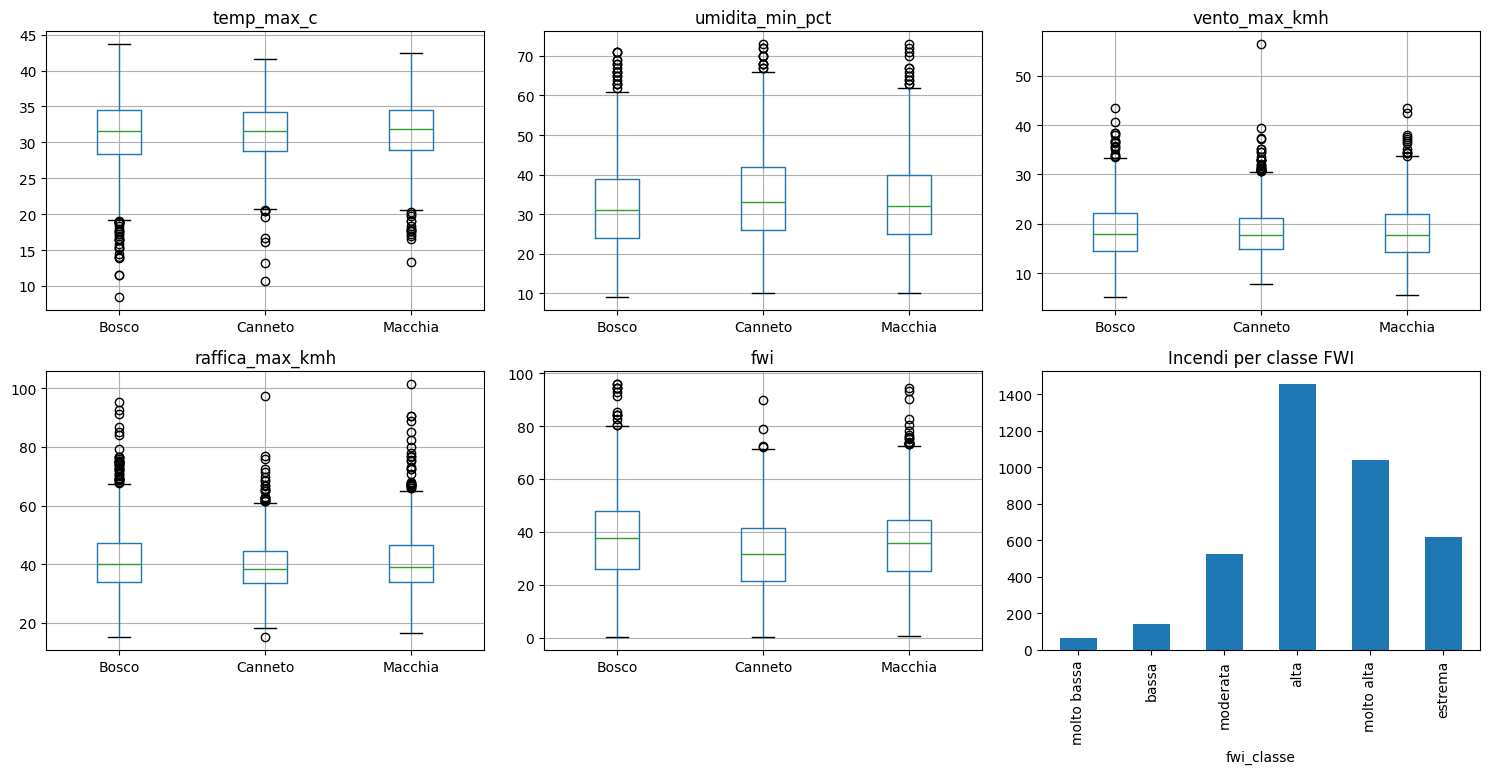

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, c in zip(ax.flat, ["temp_max_c", "umidita_min_pct", "vento_max_kmh", "raffica_max_kmh", "fwi"]):
    out.boxplot(column=c, by="tipologia", ax=a); a.set_title(c); a.set_xlabel("")
out["fwi_classe"].value_counts().reindex(CLASSI).plot.bar(ax=ax.flat[5], title="Incendi per classe FWI")
plt.suptitle(""); plt.tight_layout(); plt.show()

In [ ]:
print("Incendi con pioggia nel giorno stesso (> 1 mm):", (out.pioggia_giorno_mm > 1).sum(),
      "-> da guardare: possibile data errata o pioggia locale non vista dal modello")

In [ ]:
SETTORI = ["Tramontana (N)", "Grecale (NE)", "Levante (E)", "Scirocco (SE)",
           "Ostro (S)", "Libeccio (SO)", "Ponente (O)", "Maestrale (NO)"]
PUNTI = ["N", "NE", "E", "SE", "S", "SO", "O", "NO"]

def settore(gradi):
    if pd.isna(gradi):
        return None
    return int(((gradi % 360) + 22.5) // 45) % 8

d = pd.read_csv(CLEAN / "incendi_meteo.csv")
s = d["dir_vento_ore12_gradi"].map(settore)
d["vento_ore12_nome"] = s.map(lambda i: None if i is None else SETTORI[i])
d["fuoco_spinto_verso"] = s.map(lambda i: None if i is None else PUNTI[(i + 4) % 8])
d.to_csv(CLEAN / "incendi_meteo.csv", index=False, encoding="utf-8")
print(d["vento_ore12_nome"].value_counts())

vento_ore12_nome
Tramontana (N)    1442
Grecale (NE)       479
Maestrale (NO)     458
Libeccio (SO)      433
Ostro (S)          379
Ponente (O)        294
Levante (E)        184
Scirocco (SE)      184
Name: count, dtype: int64
